## Data Analytics Lab 08: Normalization

In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
# Logistic Regression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

Read the dataset

In [51]:
df = pd.read_csv('diabetes.csv')
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


1. Plot a pie chart for class distribution

<Axes: ylabel='count'>

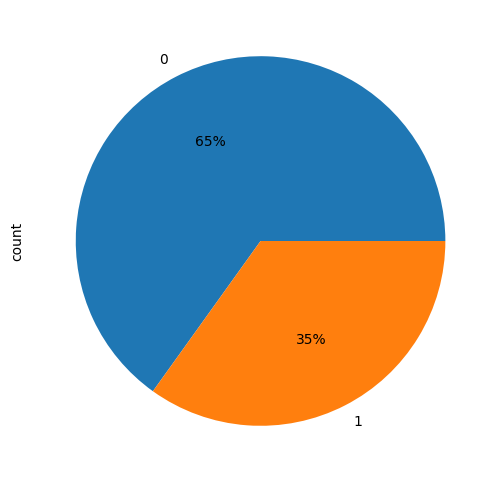

In [52]:
# Pie chart for class distribution
df['Outcome'].value_counts().plot(kind='pie', autopct='%1.0f%%', figsize=(6, 6))

2. Use Logistic Regression, evaluate the accuracy of the model on predicting of a diabetic
person.

In [53]:
# Features and target
target = 'Outcome'
features = df.columns.drop(target).tolist()
features

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [54]:
# Split into training and testing set
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
# Separate
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

In [55]:
# Model 1: Logistic Regression (no scaling)
model1 = LogisticRegression()
model1.fit(X_train, y_train)

# Evaluate accuracy
y_pred1 = model1.predict(X_test)
accuracy1 = accuracy_score(y_test, y_pred1)
print("Model 1 Accuracy:", accuracy1)

Model 1 Accuracy: 0.7402597402597403


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


3. Normalize the data with Min-Max Scaling, and use Logistic Regression, evaluate the accuracy
of the model on predicting of a diabetic person

In [56]:
# Model 2: With Min-Max Scaling on training data
min_max_scalar = MinMaxScaler()
X_train_scaled1 = min_max_scalar.fit_transform(X_train)
X_test_scaled1 = min_max_scalar.transform(X_test)
model2 = LogisticRegression()
model2.fit(X_train_scaled1, y_train)

# Evaluate accuracy
y_pred2 = model2.predict(X_test_scaled1)
accuracy2 = accuracy_score(y_test, y_pred2)
print("Model 2 Accuracy:", accuracy2)

Model 2 Accuracy: 0.7532467532467533


4. Normalize the data with Z-score Scaling, and use Logistic Regression, evaluate the accuracy of
the model on predic ng of a diabetic person.

In [57]:
# Model 3: With Z-Score Scaling on training data
min_max_scalar = StandardScaler()
X_train_scaled2 = min_max_scalar.fit_transform(X_train)
X_test_scaled2 = min_max_scalar.transform(X_test)
model3 = LogisticRegression()
model3.fit(X_train_scaled2, y_train)

# Evaluate accuracy
y_pred3 = model3.predict(X_test_scaled2)
accuracy3 = accuracy_score(y_test, y_pred3)
print("Model 3 Accuracy:", accuracy3)

Model 3 Accuracy: 0.7532467532467533


5. Compare the results of 2, 3 and 4.

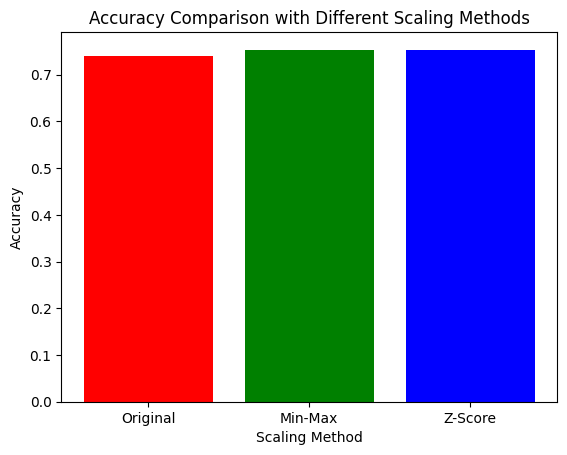

In [58]:
# Compare the accuracy with a Bar Plot
# Data for the bar plot
categories = ['Original', 'Min-Max', 'Z-Score']
values = [accuracy1, accuracy2, accuracy3]
colors = ['red', 'green', 'blue']
# Create the bar plot
plt.bar(categories, values, color=colors)
plt.xlabel('Scaling Method')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison with Different Scaling Methods')

plt.show()